In [24]:
### 导入数据
from torchvision import datasets
from torchvision.transforms import ToTensor

train_dataset = datasets.FashionMNIST('data/train',train= True, transform=ToTensor(), download= True)
test_dataset = datasets.FashionMNIST('data/test',train = False, transform=ToTensor(), download= True)


In [25]:
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn as nn
train_loader = DataLoader(train_dataset,batch_size=256,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size = 256,shuffle=False)

In [26]:
### 建立模型
import torch
import torch.nn as nn
class Classic(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.nets = nn.Sequential(
            nn.Linear(input_dim,output_dim),
            nn.ReLU()
        )
    def forward(self,x):
        return self.nets(x)

class MyModel(nn.Module):
    def __init__(self, output_dim, hidden_dim, layers ):
        super().__init__()
        self.convlayers = nn.Sequential(
            nn.Conv2d(in_channels = 1, out_channels= 10, kernel_size= 5), ### 28 - 5 + 1 = 24
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels = 10, out_channels=20, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.linerlayer = nn.Sequential(
            Classic(20*4*4,hidden_dim),
            Classic(hidden_dim,hidden_dim),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self,x):
        out = self.convlayers(x)
        out = self.linerlayer(out.view(-1,20*4*4))
        return out
    
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = MyModel(10,256,2).to(device)
print(model)

MyModel(
  (convlayers): Sequential(
    (0): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linerlayer): Sequential(
    (0): Classic(
      (nets): Sequential(
        (0): Linear(in_features=320, out_features=256, bias=True)
        (1): ReLU()
      )
    )
    (1): Classic(
      (nets): Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): ReLU()
      )
    )
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [27]:
criterion = nn.CrossEntropyLoss() ### softmax + crossentropy
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

In [28]:
### training process
import os
import matplotlib.pyplot as plt
from IPython.display import clear_output
def trainer():
    if not os.path.isdir('./models'):
        os.mkdir('./models')
    train_losses = []
    train_accs = []
    test_losses = []
    test_accs = []
    count = 0
    early_count = 20
    best_acc = 0
    num_epochs = 50
    for epoch in range(num_epochs):
        train_acc = 0
        train_loss = 0
        model.train()
        for _, batch in enumerate(tqdm(train_loader)):
            optimizer.zero_grad()
            features, labels = batch
            features, labels = features.to(device), labels.to(device)
            pred = model(features)
            _, train_pred = torch.max(pred, dim = 1)
            loss = criterion(pred, labels)
            train_loss += loss.detach().cpu().item()
            train_acc += (train_pred.detach() == labels).float().mean().item()
            loss.backward()
            optimizer.step()

        train_losses.append(train_loss / len(train_loader))
        train_accs.append(train_acc / len(train_loader))

        test_loss = 0
        test_acc = 0
        if len(test_loader.dataset) > 0:
            model.eval()
            for _, batch in enumerate(tqdm(test_loader)):
                features, labels = batch
                features, labels = features.to(device), labels.to(device)
                with torch.no_grad():
                    pred = model(features) ### (batch_size, num)
                    loss = criterion(pred,labels)
                    _, test_pred = torch.max(pred, dim = 1)
                test_loss += loss.cpu().item()
                test_acc += (test_pred == labels).float().mean().item()
            test_loss /= len(test_loader)
            test_acc /= len(test_loader)

            test_losses.append(test_loss)
            test_accs.append(test_acc)



            if test_acc > best_acc:
                best_acc = test_acc
                count = 0
                print(f"训练第 {epoch+1} 次，当前的 acc 为 {best_acc}")
                torch.save(model.state_dict(), f = './models/model.pt')
            else:
                count += 1
                if count >= early_count:
                    break
        # ===== 每隔 10 个 epoch 刷新一次图 =====
        if (epoch + 1) % 10 == 0 or epoch == 0:
            clear_output(wait=True)   # 清掉上一个图，不重刷整个页面
            
            plt.figure(figsize=(12, 5))
            
            plt.subplot(1, 2, 1)
            plt.plot(train_losses, label='Train Loss')
            if test_losses:
                plt.plot(test_losses, label='Test Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.title(f'Loss Curve (Epoch {epoch+1})')
            
            plt.subplot(1, 2, 2)
            plt.plot(train_accs, label='Train Acc')
            if test_accs:
                plt.plot(test_accs, label='Test Acc')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy')
            plt.legend()
            plt.title(f'Accuracy Curve (Epoch {epoch+1})')
            
            plt.tight_layout()
            plt.show()
        


    return train_losses, train_accs, test_losses, test_accs


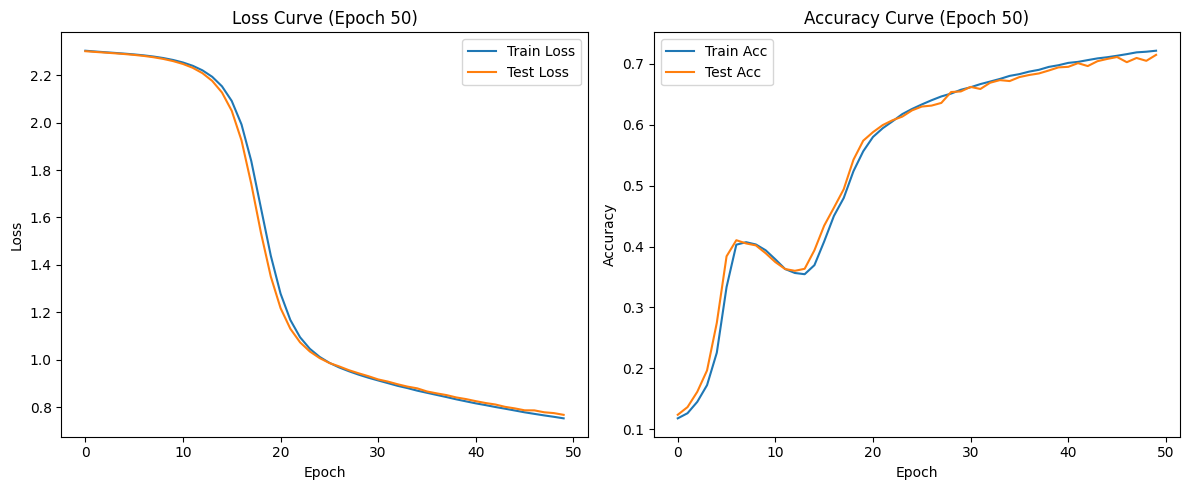

([2.3028879804814117,
  2.299601181517256,
  2.296607214339236,
  2.293712282180786,
  2.2906616109482787,
  2.2872593524608207,
  2.283236592881223,
  2.27826971804842,
  2.2719355786100346,
  2.2637933274532887,
  2.253293794266721,
  2.2394126892089843,
  2.2201209453826256,
  2.1928859730984303,
  2.152787559590441,
  2.091031165833169,
  1.9920506974484058,
  1.837854975842415,
  1.6382459792685002,
  1.4388316139261774,
  1.2790091824024281,
  1.1681041220401196,
  1.0949554144067968,
  1.04629177666725,
  1.0123195224619925,
  0.9873144504871775,
  0.9678239520559919,
  0.9518594424775306,
  0.9373555163119701,
  0.9244523733220202,
  0.9129170547140405,
  0.901631243178185,
  0.8901491499961691,
  0.8807367096555994,
  0.8699567896254519,
  0.8608629094793442,
  0.8518761683017649,
  0.8428729277976016,
  0.833392021757491,
  0.8248011360777185,
  0.8163808807413628,
  0.8089995825544317,
  0.8010224365173502,
  0.7938258876191809,
  0.7862959351945431,
  0.778658710388427,
  0

In [29]:
trainer()